## Quick start
After cloning the repository, the package may be installed with `pip` in the regular way. From the repository root run:

```bash
pip install .
```
The following code plots a two dimensional density slice.

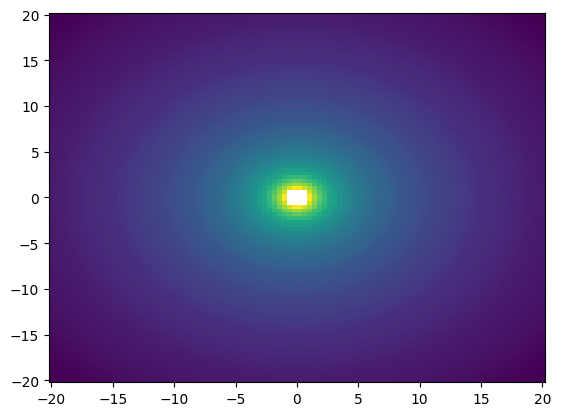

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from starwinds_readplt.dataset import Dataset
from batcamp import Octree, OctreeInterpolator

# Read the dataset
ds = Dataset.from_file("../example_data/3d__var_4_n00000000.plt")

# Create the octree and interpolator (this file is spherical/rpa)
tree = Octree.from_dataset(ds, coord_system="rpa")
interp = OctreeInterpolator(ds, ["Rho [g/cm^3]"], tree=tree, query_coord="xyz")

# Create a Cartesian slice and interpolate density
X, Y = np.meshgrid(np.linspace(-20, 20, 100), np.linspace(-20, 20, 100))
Z = np.zeros_like(X)
rho = interp(X, Y, Z, query_coord="xyz")

fig, ax = plt.subplots()
ax.pcolormesh(X, Y, rho, norm="log")
ax.set_title("3d__var_4_n00000000.plt")
plt.show()


In [ ]:
from pathlib import Path
import pooch


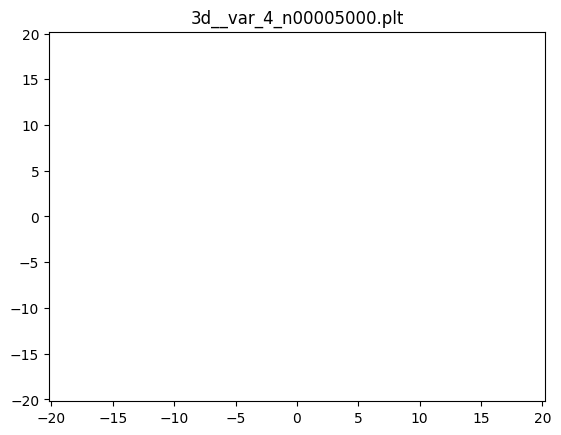

In [ ]:
file = pooch.retrieve(
    url="https://zenodo.org/records/7110555/files/run-Sun-G2211.tar.gz",
    known_hash="c31a32aab08cc20d5b643bba734fd7220e6b369e691f55f88a3a08cc5b2a2136",
    progressbar=True,
    processor=pooch.Untar(members=[
        "run-Sun-G2211/SC/IO2/3d__var_4_n00044000.plt",
    ]),
)
if isinstance(file, (list, tuple)):
    file = file[0]

# Read the dataset
ds = Dataset.from_file(file)

# SC file is spherical/rpa
tree = Octree.from_dataset(ds, coord_system="rpa")
interp = OctreeInterpolator(ds, ["Rho [g/cm^3]"], tree=tree, query_coord="xyz")

# Cartesian slice
X, Y = np.meshgrid(np.linspace(-20, 20, 100), np.linspace(-20, 20, 100))
Z = np.zeros_like(X)
rho = interp(X, Y, Z, query_coord="xyz")

plt.pcolormesh(X, Y, rho, norm="log")
plt.title(Path(file).name)
plt.show()


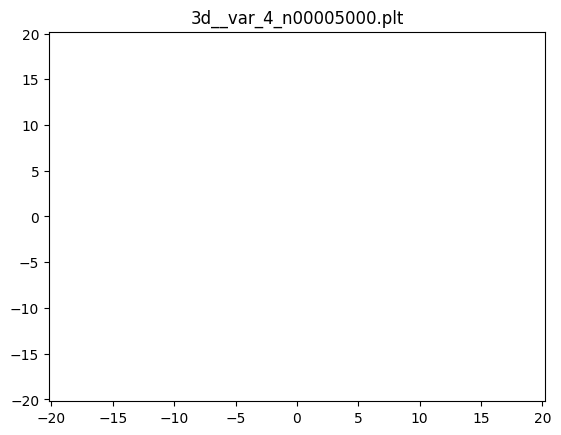

In [ ]:
file = pooch.retrieve(
    url="https://zenodo.org/records/7110555/files/run-Sun-G2211.tar.gz",
    known_hash="c31a32aab08cc20d5b643bba734fd7220e6b369e691f55f88a3a08cc5b2a2136",
    progressbar=True,
    processor=pooch.Untar(members=[
        "run-Sun-G2211/IH/IO2/3d__var_4_n00005000.plt",
    ]),
)
if isinstance(file, (list, tuple)):
    file = file[0]

# Read the dataset
ds = Dataset.from_file(file)

# IH file is Cartesian/xyz
tree = Octree.from_dataset(ds, coord_system="xyz")
interp = OctreeInterpolator(ds, ["Rho [g/cm^3]"], tree=tree, query_coord="xyz")

# Cartesian slice
X, Y = np.meshgrid(np.linspace(-20, 20, 100), np.linspace(-20, 20, 100))
Z = np.zeros_like(X)
rho = interp(X, Y, Z, query_coord="xyz")

plt.pcolormesh(X, Y, rho, norm="log")
plt.title(Path(file).name)
plt.show()


In [22]:
file

'/Users/dagfev/Library/Caches/pooch/8c62a596be9356ac52956bdee5198bec-run-Sun-G2211.tar.gz.untar/run-Sun-G2211/IH/IO2/3d__var_4_n00005000.plt'